
################################################################################
DATASET 2 - 6/7 Features (con/senza sentiment)
################################################################################
Scaler 'financial' estratto dal dizionario da C:/Users/angel/OneDrive/Desktop/ProgettoMeDL/Financial_Forecasting_XAI\data_split_titolo\scaler.pkl

Shape X_test: (190, 60, 7)
Shape y_test: (190,)

############################################################
Valutazione Modello: LSTM 6_Dataset2
############################################################
Modello Keras caricato: C:/Users/angel/OneDrive/Desktop/ProgettoMeDL/Financial_Forecasting_XAI\notebooks/modello_finale.keras
 Sentiment rimosso: shape (190, 60, 7) -> (190, 60, 6)
 History caricata: C:/Users/angel/OneDrive/Desktop/ProgettoMeDL/Financial_Forecasting_XAI\notebooks/cronologia_addestramento.joblib
Grafico salvato in: C:/Users/angel/OneDrive/Desktop/ProgettoMeDL/Financial_Forecasting_XAI\notebooks/modello_finale_learni

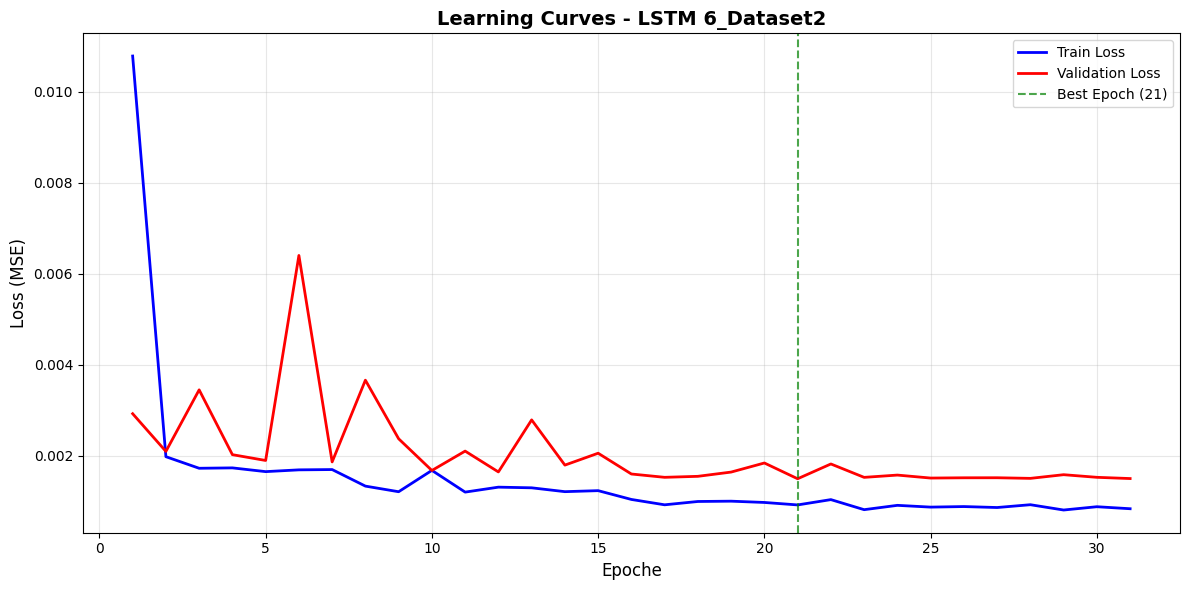

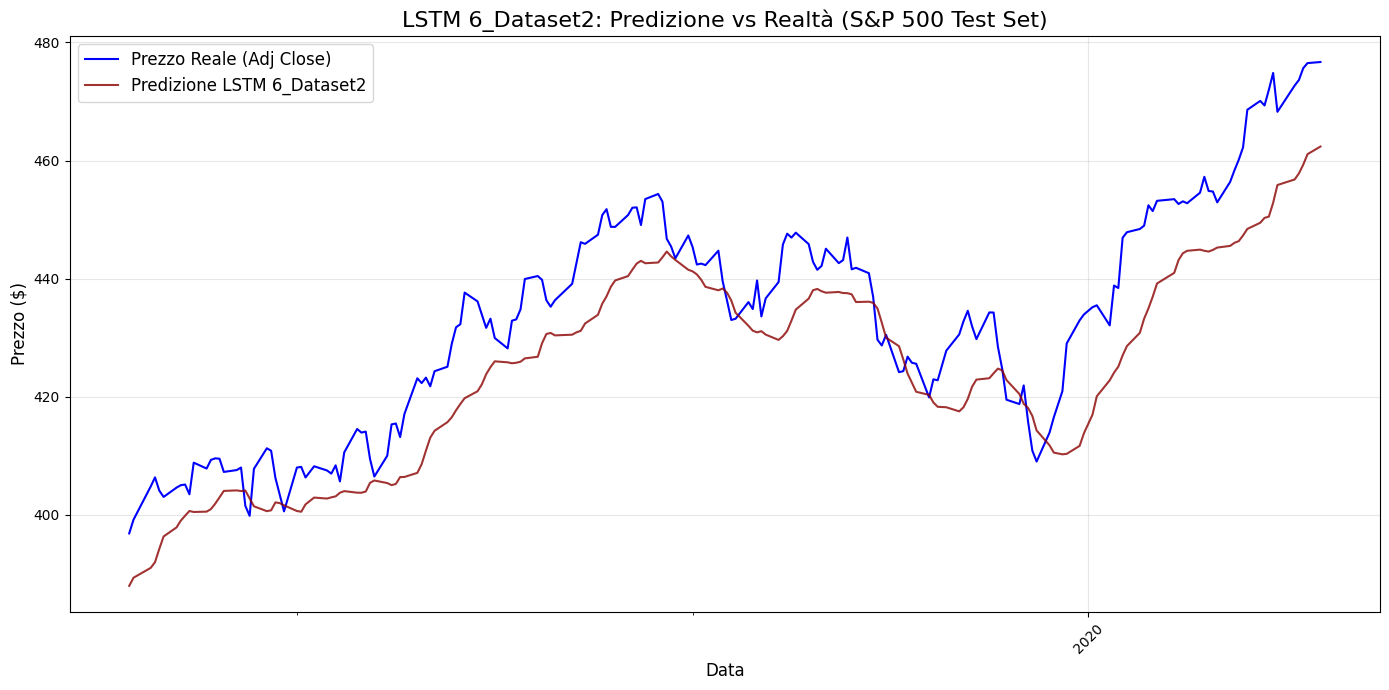


VALUTAZIONE COMPLETATA!


In [ ]:
import os
import sys
import joblib
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from utils.visualizzazione import evaluate_and_plot

CSV_PATH = 'C:/Users/angel/OneDrive/Desktop/ProgettoMeDL/SPY.csv'
BASE_DIR = 'C:/Users/angel/OneDrive/Desktop/ProgettoMeDL/Financial_Forecasting_XAI'



DATASET2_DIR = os.path.join(BASE_DIR, 'data_split_titolo')
DATASET2_MODELS = {
    'LSTM_6': os.path.join(BASE_DIR, 'notebooks/modello_finale.keras')
}
DATASET2_HISTORY = {
    'LSTM_6': os.path.join(BASE_DIR, 'notebooks/cronologia_addestramento.joblib')
}

# Scaler paths
SCALER_DATASET2 = os.path.join(DATASET2_DIR, 'scaler.pkl')




def load_scaler(scaler_path):
    scaler_loaded = joblib.load(scaler_path)
    if isinstance(scaler_loaded, dict) and 'financial' in scaler_loaded:
        scaler = scaler_loaded['financial']
        print(f"Scaler 'financial' estratto dal dizionario da {scaler_path}")
    else:
        scaler = scaler_loaded
        print(f" Scaler caricato direttamente da {scaler_path}")
    return scaler


def calculate_overfitting_metrics(history):
    if history is None:
        return None
    
    
    h_dict = history.history if hasattr(history, 'history') else history
    
    train_loss = h_dict['loss']
    val_loss = h_dict['val_loss']
    
    # Loss finale
    final_train_loss = train_loss[-1]
    final_val_loss = val_loss[-1]
    
    # Gap tra train e validation
    gap_percentage = ((final_val_loss - final_train_loss) / final_train_loss) * 100
    
    # Migliore val_loss
    best_val_loss = min(val_loss)
    best_epoch = val_loss.index(best_val_loss) + 1
    
    # Degrado dopo best epoch
    degradation = final_val_loss - best_val_loss
    degradation_percentage = (degradation / best_val_loss) * 100    
    metrics = {
        'final_train_loss': final_train_loss,
        'final_val_loss': final_val_loss,
        'gap_percentage': gap_percentage,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'degradation': degradation,
        'degradation_percentage': degradation_percentage,
        'total_epochs': len(train_loss)    }
    
    return metrics


import matplotlib.pyplot as plt

def calculate_overfitting_metrics(h_dict):
    best_epoch = h_dict['val_loss'].index(min(h_dict['val_loss'])) + 1
    return {'best_epoch': best_epoch}

def plot_learning_curves_enhanced(history, model_name="Modello", save_path=None):
    if history is None:
        print(f"Nessuna history disponibile per {model_name}")
        return
    
    h_dict = history.history if hasattr(history, 'history') else history
    
    metrics = calculate_overfitting_metrics(h_dict)
    
    fig, ax1 = plt.subplots(figsize=(12, 6)) 
    
    # Plot 1: Learning Curves
    epochs = range(1, len(h_dict['loss']) + 1)
    ax1.plot(epochs, h_dict['loss'], 'b-', label='Train Loss', linewidth=2)
    ax1.plot(epochs, h_dict['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    
    # Linea verticale per la miglior epoca
    ax1.axvline(x=metrics['best_epoch'], color='green', linestyle='--', 
                label=f'Best Epoch ({metrics["best_epoch"]})', alpha=0.7)
    
    ax1.set_title(f'Learning Curves - {model_name}', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoche', fontsize=12)
    ax1.set_ylabel('Loss (MSE)', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    plt.tight_layout()

    # Gestione salvataggio o visualizzazione
    if save_path:
        plt.savefig(save_path)
        print(f"Grafico salvato in: {save_path}")
    else:
        plt.show()
    
    # Stampa metriche
    print(f"\n{'='*60}")
    print(f"ANALISI OVERFITTING - {model_name}")


def evaluate_model(model_path, history_path, X_test, y_test, scaler, 
                   model_name, color='blue', remove_sentiment=False):
    print(f"\n{'#'*60}")
    print(f"Valutazione Modello: {model_name}")
    print(f"{'#'*60}")
    
    if model_path.endswith('.keras'):
        model = load_model(model_path)
        print(f"Modello Keras caricato: {model_path}")
    elif model_path.endswith('.pkl'):
        model = joblib.load(model_path)
        print(f" Modello Scikit-learn caricato: {model_path}")
    else:
        raise ValueError(f"Formato modello non supportato: {model_path}")
    
    X_test_processed = X_test.copy()
    if remove_sentiment and X_test.shape[-1] == 7:
        X_test_processed = X_test[:, :, :-1]
        print(f" Sentiment rimosso: shape {X_test.shape} -> {X_test_processed.shape}")
    
    if history_path and os.path.exists(history_path):
        history = joblib.load(history_path)
        print(f" History caricata: {history_path}")
        
        plot_save_path = model_path.replace('.keras', '_learning_curves.png').replace('.pkl', '_learning_curves.png')
        plot_learning_curves_enhanced(history, model_name, save_path=plot_save_path)
    else:
        print(f" Nessuna history disponibile per {model_name}")
        history = None
    
    # Valutazione finale
    print(f"\nValutazione su Test Set:")
    evaluate_and_plot(
        model=model,
        X_test=X_test_processed,
        y_test=y_test,
        scaler=scaler,
        csv_path=CSV_PATH,
        model_name=model_name,
        color=color
    )



def main():
    print("\n" + "#"*80)
    print("DATASET 2 - 6/7 Features (con/senza sentiment)")
    print("#"*80)
    
    X_test_d2 = np.load(os.path.join(DATASET2_DIR, 'X_test.npy'))
    y_test_d2 = np.load(os.path.join(DATASET2_DIR, 'y_test.npy'))
    scaler_d2 = load_scaler(SCALER_DATASET2)
    
    print(f"\nShape X_test: {X_test_d2.shape}")
    print(f"Shape y_test: {y_test_d2.shape}")
    
    colors_d2 = {'LSTM_6': 'darkred'}
    
    for model_key in ['LSTM_6']:
        if os.path.exists(DATASET2_MODELS[model_key]):
            remove_sentiment = model_key.endswith('_6') and X_test_d2.shape[-1] == 7
            evaluate_model(
                model_path=DATASET2_MODELS[model_key],
                history_path=DATASET2_HISTORY[model_key],
                X_test=X_test_d2,
                y_test=y_test_d2,
                scaler=scaler_d2,
                model_name=f'{model_key.replace("_", " ")}_Dataset2',
                color=colors_d2[model_key],
                remove_sentiment=remove_sentiment
            )
        else:
            print(f"Modello non trovato: {DATASET2_MODELS[model_key]}")
    
    print("\n" + "="*80)
    print("VALUTAZIONE COMPLETATA!")
    print("="*80)


if __name__ == "__main__":
    main()